In [1]:
import pandas as pd

In [2]:
tokenised_prompt = pd.read_pickle("tokenised_prompt.pkl")

In [3]:
tokenised_prompt.head()

,attention_mask,input_ids
0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
2,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
3,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
4,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."


In [4]:
!pip install torch transformers datasets accelerate peft bitsandbytes

In [5]:
model_id = "google/gemma-2b"

In [6]:
from transformers import AutoModelForCausalLM

In [10]:
from huggingface_hub import notebook_login
notebook_login()

In [11]:
model = AutoModelForCausalLM.from_pretrained(model_id)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [12]:
from transformers import AutoTokenizer

In [13]:
model_id = "google/gemma-2b"
tokeniser = AutoTokenizer.from_pretrained(model_id)
print("model loaded succesfully")

model loaded succesfully


In [14]:
prompt = "If 4x + i(3x – y) = 3 + i (– 6), where x and y are real numbers, then find the values of x and y."
tokenised_prompt = tokeniser(prompt)

In [15]:
tokenised_prompt

{'input_ids': [2, 2495, 235248, 235310, 235297, 963, 496, 235278, 235304, 235297, 1157, 597, 235275, 589, 235248, 235304, 963, 496, 591, 235389, 235248, 235318, 823, 1570, 1141, 578, 597, 708, 1879, 5968, 235269, 1492, 1717, 573, 4035, 576, 1141, 578, 597, 235265], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [16]:
input_id = tokenised_prompt["input_ids"]

In [17]:
import torch

In [18]:
input_id = torch.tensor(input_id)
d = len(input_id)

In [19]:
input_id = input_id.reshape([1 , d])

In [20]:
input_id

tensor([[     2,   2495, 235248, 235310, 235297,    963,    496, 235278, 235304,
         235297,   1157,    597, 235275,    589, 235248, 235304,    963,    496,
            591, 235389, 235248, 235318,    823,   1570,   1141,    578,    597,
            708,   1879,   5968, 235269,   1492,   1717,    573,   4035,    576,
           1141,    578,    597, 235265]])

In [21]:
# output_id = model.generate(input_id)

In [22]:
# output_id

In [23]:
# tokeniser.decode(output_id[0])

In [24]:
tokenised_data = pd.read_pickle("tokenised_prompt.pkl")

In [25]:
# creating a dataloader
import torch
from torch.utils.data import DataLoader
from datasets import Dataset


In [26]:
tokenised_data.head()

,attention_mask,input_ids
0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
2,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
3,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."
4,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 235276, 141, 204, 235322, 235371, 1645, 23..."


In [27]:
tokenised_df = Dataset.from_pandas(tokenised_data)

In [28]:

tokenised_df.set_format(
    type = "torch",
    columns = ["attention_mask", "input_ids"]
)

In [29]:
from transformers import DataCollatorWithPadding

In [30]:
data_collator = DataCollatorWithPadding(tokeniser)

In [31]:
dataloader = DataLoader(
    tokenised_df,
    batch_size = 4,
    shuffle = True,
    collate_fn = data_collator
)

In [32]:
# what do we need for lora
# rank = 16
# lora alpha = 32
# task_type = CASUAL_LM
# target_module = q_proj, k_proj, v_proj



In [33]:
from peft import LoraConfig, LoraModel # what does "LoraModel" do?

In [34]:
lora_config = LoraConfig(
    r = 16, lora_alpha = 32,
    target_modules = ["q_proj", "o_proj", "k_proj", "v_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout = 0.1,
    task_type="CAUSAL_LM"
)

In [35]:
lora_model = LoraModel(
    model, lora_config, "default"
)

In [36]:
lora_model = lora_model.to("cuda")

In [37]:
params = []
for param in lora_model.parameters():
  if param.requires_grad == True:
    params.append(param)


In [38]:
loss_fn = torch.nn.CrossEntropyLoss()
optimiser = torch.optim.AdamW(params = params, lr=0.001)


model.train()

loop for epochs

loop for every datapoints

move batch to cuda

perform forward loss

get loss

perform backward pass


update weights

zero the optimiser gradient




In [39]:
device = "cuda"
from tqdm import tqdm


In [40]:
epochs = 3
training_loss = []
lora_model = lora_model.to(device)

In [41]:
lenght_of_attention_mask = []
lenght_of_inputIds = []
for n , batch in enumerate(dataloader):
  for name , related_tensor in batch.items():
    if name == "attention_mask":
      lenght_of_attention_mask.append(len(related_tensor))
    else:
      lenght_of_inputIds.append(len(related_tensor))

In [42]:
print(n)

142


In [43]:
print(lenght_of_inputIds[:10])

[4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


In [44]:
for batch in dataloader:
  batch = {name : related_tensor.to(device) for name , related_tensor in batch.items()}
  outputs = lora_model(**batch)
  print(outputs.loss)
  break

None


In [45]:
lora_model.train()
for i in range(epochs):
  total_loss = 0
  for batch in tqdm(dataloader):
      batch = {name : related_tensor.to(device) for name , related_tensor in batch.items()}
      labels = batch["input_ids"]
      outputs = lora_model(**batch, labels = labels)
      loss = outputs.loss
      loss.backward()
      optimiser.step()
      optimiser.zero_grad()
      total_loss += loss
      training_loss.append(loss)
  avg_loss = total_loss / len(dataloader)
  print(f"avergae loss of {i+1}th epochs is {avg_loss}")

100%|██████████| 143/143 [01:20<00:00,  1.77it/s]


avergae loss of 1th epochs is 2.6866416931152344


100%|██████████| 143/143 [01:28<00:00,  1.61it/s]


avergae loss of 2th epochs is 1.8582391738891602


100%|██████████| 143/143 [01:27<00:00,  1.63it/s]

avergae loss of 3th epochs is 9.339296340942383


In [47]:
training_loss = [float(t.to("cpu").detach()) for t in training_loss]

In [48]:
from  math import log10
log_loss = [log10(x) for x in training_loss]

In [49]:
number_iter = [i+1 for i in range(429)]

In [50]:
import seaborn as sns

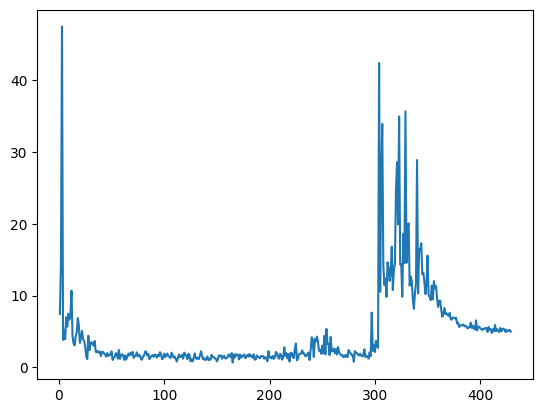

In [52]:
sns.lineplot(y = training_loss, x = number_iter);

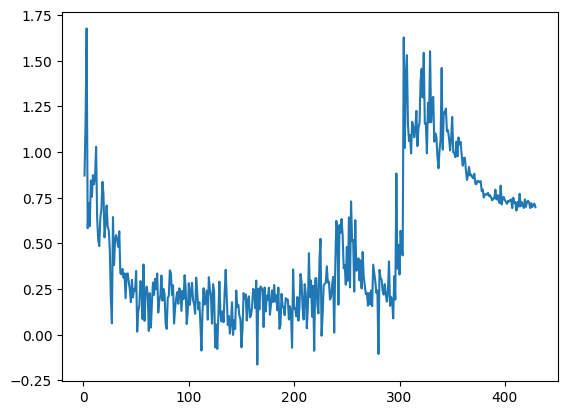

In [53]:
sns.lineplot(y = log_loss, x = number_iter);

AttributeError: 'GemmaForCausalLM' object has no attribute 'save_pretrained_gguf'